# NOTES
## Preprocessing steps
1. Define bad and dead channels
    - note: manual inspection first? The authors seemed to go in loops and find the bad channels after all the preprocessing are done (artifacts found in autorejects and IC rejections)
For (each participant):
2. Downsample (1000Hz -> 250Hz)
    - note: original data has 260Hz low pass filter
3. Bandpass Filter (0.1, 30Hz)
4. Remove 50Hz. Original paper: notch Filter (50Hz (48, 52, 1))
5. Remove bad channels (if more than 4: remove participant)
6. Rerefenrence (mastoid)
7. Isolate some data to run ICA (epoching? starting with each new cue)
8. Remove bad trials (find artifacts)
9. Run ICA
10. Perform auto-rejection per ICLabel
11. Interpolation

>NOTE: two-pass preprocessing: go through the preprocessing steps once and then see if there is still bad channels remaining. if so, mark them and start over again.

>NOTE: cannot make a copy of eeg(1-100Hz) for ICA following authors pipeline bc the noises are too many and would cause all the trials to be rejected.

## To do list
- change the erp calculation
- optimize the ica plotting. show which IC components are rejected
- statistical analysis

## Additional
- maybe try out different pipeline
- further analysis

https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html
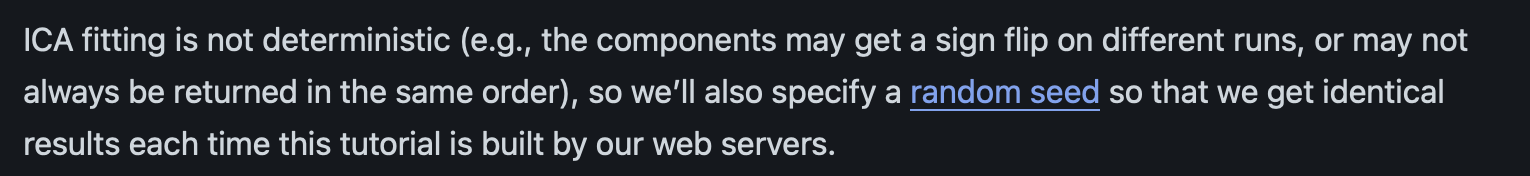

## Things to consider
- do we include the participants that are marked as non-learners by the author? or do we change the criteria a bit? (e.g. 60% -> 55%)
- do we stick to the criteria for early trial rejection? maybe instead of eliminating we can compare between learners and non-learners
- aside from eye blinks, should we reject other ic components? (e.g., heartbeat, muscle, channel noise, other)
- maybe analysis across time to show the effect of learning?

**NOTES**
- nonLearners = [3 5 9 12 20 24 25 29 30 32 33]

## Results under current condition
- condition: IC rejection - eye blink > 50%

| Subject ID | Author | ours(1) | ours(2) | Notes |
|---|---|---|---|---|
| 27 | N/A | N/A | N/A | |
| 28 | N/A | N/A | N/A | |
| 29 (non learner) | N/A | N/A | | |
| 30 (non learner) | N/A | N/A | | pretty obvious channel noise at Fp1, but does not surpass the threshold \(15%\)|
| 31 | N/A | N/A | | regular troughs that look like heartbeat but not shown in ic anaylsis. need double check |
| 32 (non learner) | TP10 | N/A | | line noise present after bandpass - prove that notch filter is still necessary|
| 33 (non learner) | N/A | N/A | | muscle artifacts present but then no epochs is rejected after ica |
| 34 | N/A | N/A | | channel noise and heart beat present but no epochs is rejected after ica |
| 35 | N/A | N/A | | TP9 and TP10 are needed for interpolation. Probably bc 'other' in ICA, ugly artifacts across all channels in the plot. Need to change the current IC rejeciton criteria if we follow the same pipeline|
| 36 | N/A | N/A | | channel noise present. the regular troughs again. again only a few epochs are rejected after ica |
| 37 | N/A | N/A | | the regular troughs again. again only a few epochs are rejected after ica|
| 38 | N/A | N/A | | heart beat present but no epochs is rejected after ica |
| | | | General notes | From manual inspection there seem to be still artifacts (looks regular) after cleaning (not sure if its normal brain reaction after sitmulus or eyeblinks or heartbeats, need to take a second look.)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import mne
from mne_bids import (BIDSPath,read_raw_bids)
import sys
sys.path.insert(0,'.')
import os


import ccs_eeg_utils
import config
from tools import get_valid_input, get_event_dict
from visualization import show_single_psd, psd_compare, iclabel_visualize, plot_erp
from s00_add_reference import add_reference_channel
from s01_downsample_filter import down_sampling, band_filter, notch_filter, zapline_filter
from s02_drop_bad_channels import drop_bad_channels, reref, average_reference
from s03_07_trial_rejection import trial_rejection_cust, trial_rejection_mne
from s04_ICA import get_ica, get_iclabel, iccomponent_removal_author, iccomponent_removal_new
from s05_interpolation import interpolation
from s06_early_trial_removal import exclude_early_trials
from s07_epoching import epoching, epoching_cust
from s08_find_bad_channels import find_bad_channels
from s09_make_erps import get_evoked, get_evoked_difference
from s10_rewp_calculation import rewp_calculation

# Set the configs

In [3]:
ACTIVE_PIPELINE = get_valid_input(
    'Select active pipeline (options: original/proposed): ',
    list(config.PIPELINES.keys())
)

USER = get_valid_input(
    'Select the user (options: qian/zheng): ',
    list(config.BIDS_ROOT.keys())
)

INSPECTION_MODE = get_valid_input(
    'Do you want to inspect the intermediate results? (options: True/False): ',
    ['True', 'False']
)

Input accepted:original
Input accepted:zheng
Input accepted:true


In [4]:
SUBJECT = get_valid_input(
    'Select the subject id (options: 27 - 38): ',
    list(config.SUBJECT_INFO.keys())
)

FIRST_RUN = get_valid_input(
    'Is this the first run for the subject? (options: True/False): ',
    ['True', 'False']
)

Input accepted:32
Input accepted:true


In [5]:
### set up paths and read in data
cfg = config.PIPELINES[ACTIVE_PIPELINE]
root = config.BIDS_ROOT[USER]

bids_path = BIDSPath(subject=SUBJECT, task='casinos',
                     datatype='eeg', suffix='eeg',
                     root=root)

# read the file
raw = read_raw_bids(bids_path)
# fix the annotations readin
ccs_eeg_utils.read_annotations_core(bids_path,raw)

### montage setup
montage_site2_path = os.path.join(root, 'code', config.LOCS_FILENAME['site2']) 
montage_site2 = mne.channels.read_custom_montage(montage_site2_path)
montage_common_path = os.path.join(root, 'code', config.LOCS_FILENAME['common'])
montage_common = mne.channels.read_custom_montage(montage_common_path)

### Dictionary for epoching conditions
ica_trial_dict = config.CONDITIONS_DICT['onset_locked']
epoch_dict = config.CONDITIONS_DICT['feedback_locked']

### Subject info list
subject_info = config.SUBJECT_INFO

Extracting parameters from C:\Users\Zheng\Desktop\fourth semester\EEG\reward_dataset\reward_dataset\reward_dataset\sub-32\eeg\sub-32_task-casinos_eeg.vhdr...
Setting channel info structure...
Reading events from C:\Users\Zheng\Desktop\fourth semester\EEG\reward_dataset\reward_dataset\reward_dataset\sub-32\eeg\sub-32_task-casinos_events.tsv.
The event "Stimulus" refers to multiple event values.Creating hierarchical event names.
    Renaming event: Stimulus -> Stimulus/S  1
    Renaming event: Stimulus -> Stimulus/S  2
    Renaming event: Stimulus -> Stimulus/S  3
    Renaming event: Stimulus -> Stimulus/S  4
    Renaming event: Stimulus -> Stimulus/S  7
    Renaming event: Stimulus -> Stimulus/S  1
    Renaming event: Stimulus -> Stimulus/S  2
    Renaming event: Stimulus -> Stimulus/S  3
    Renaming event: Stimulus -> Stimulus/S  1
    Renaming event: Stimulus -> Stimulus/S  2
    Renaming event: Stimulus -> Stimulus/S  3
    Renaming event: Stimulus -> Stimulus/S  1
    Renaming even

C:\Users\Zheng\AppData\Local\Temp\ipykernel_31432\379522136.py:10: RuntimeWarning: Unable to map the following column(s) to to MNE:
participant: 32
date: 07-Apr-2022 13:33:53
handedness: R
order: 50-50 80-20 mixed
stimuli: a cherry an orange
  raw = read_raw_bids(bids_path)


# Load the dataset

In [6]:
#raw.plot()     # visualize raw data
#raw.get_data()  # extract data as numpy
raw.load_data()  # load to memory

Reading 0 ... 2808479  =      0.000 ...  2808.479 secs...


<RawBrainVision | sub-32_task-casinos_eeg.eeg, 31 x 2808480 (2808.5 s), ~664.3 MiB, data loaded>

>NOTE: from manual inspection, Fp1 and Fp2 have obvious eye blinking artifacts. T7 and T8 seem to have muscle artifacts. (but leave it as it is right now)

# Add Reference

>NOTE: theres a differece in ERP value w/ and w/o re-reference

In [7]:
raw = add_reference_channel(raw, 'Fz')  # add Fz as reference channel

# Set the Montage

In [8]:
raw.set_montage(montage_site2, match_case=False)

<RawBrainVision | sub-32_task-casinos_eeg.eeg, 32 x 2808480 (2808.5 s), ~685.7 MiB, data loaded>

# Downsample

In [9]:
eeg_down = down_sampling(raw.copy())

Original Sampling Rate: 250.0 Hz
New Sampling Rate: 250.0 Hz


# Bandpass

In [10]:
eeg_band = band_filter(eeg_down.copy())

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 out of  32 | elapsed:    3.0s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done  29 out of  32 | elapsed:    3.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  32 out of  32 | elapsed:    3.4s finished


# Create seperate eeg copy for ICA

In [11]:
if ACTIVE_PIPELINE != 'original':
    # bandpass the input to fit the range of iclabel
    eeg_ica = band_filter(eeg_down.copy(), f_low=1, f_high=100)

# Remove 50Hz Noise

## Option 1: Notch filter

Original setting:  `EEG = pop_eegfiltnew(EEG, 48, 52,[],1)`

In [12]:
eeg_band_notch = notch_filter(eeg_band.copy())
if ACTIVE_PIPELINE != 'original':
    # bandpass the input to fit the range of iclabel
    eeg_ica = notch_filter(eeg_ica.copy())

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 out of  32 | elapsed:    0.5s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  29 out of  32 | elapsed:    0.6s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  32 out of  32 | elapsed:    0.6s finished


## Option 2: Zapline filter

In [64]:
if INSPECTION_MODE == True:
    eeg_band_zap = zapline_filter(eeg_band.copy())

    # for sanity test
    #NOTE: when applied on the downsample eeg (not band filtered), zapline does remove the peak at 50Hz (check if zapline is really working)
    eeg_down_zap = zapline_filter(eeg_down.copy())


# Examine the Effect of Filtering

## Raw vs. Downsampled vs. Bandpass-filtered

In [65]:
if INSPECTION_MODE == True:
    show_single_psd(raw, title="PSD for Raw EEG")
    show_single_psd(eeg_down, title="PSD for Downsampled EEG")
    show_single_psd(eeg_band, title="PSD for Bandpass-filtered EEG")


>NOTE: as shown on the plot, after band filter the line noise at 50Hz is barely visible

## Bandpass-filtered vs. Band+Notch vs. Band+Zapline

In [66]:
if INSPECTION_MODE == True:
    psd_compare((eeg_band, eeg_band_notch, eeg_band_zap), labels=("eeg_band", "eeg_band_notch", "eeg_band_zap"), title="Comparison of Filter Effects for 50Hz")

>NOTE: The leftover noise on 50Hz is negaligable and Zapline is not doing much after the bandpass filter. Choose notch?

In [16]:
if INSPECTION_MODE == True:
    show_single_psd(eeg_band_zap, title="PSD after bandpass&notch&zapline")

In [17]:
if INSPECTION_MODE == True:
    show_single_psd(eeg_down_zap, title="PSD for Zap-filtered (no bandpass) EEG")     # show that zapline can indeed remove 50Hz effectively if there is no bandpass applied before it

# Drop Bad Channels

>NOTE: not quite sure but i think they dropped the bad channel for ICA analysis, but need a copy (with bad channels) for interpolation

> NOTE: should we drop channels for ICA analysis? (is droppping bad channels for ICA only or both?)

In [13]:
if not FIRST_RUN:
    eeg_band_notch = drop_bad_channels(subject_info[SUBJECT]['bad_channels'], eeg_band_notch)   #input: bad channels from previous run, eeg

    if ACTIVE_PIPELINE != 'original':
        eeg_ica = drop_bad_channels(subject_info[SUBJECT]['bad_channels'], eeg_ica)

# Re-referencing

>NOTE: tba - reason for choosing mastoid

If only use one channel for reference, the reference channel should be dropped otherwise would influence trail rejection

In [14]:
eeg_band_notch = reref(eeg_band_notch)

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


In [15]:
if ACTIVE_PIPELINE != 'original':
    # in our pipeline, we follow the standard that input for ica should be 1-100 hz, using average mean reference
    eeg_ica = average_reference(eeg_ica)

# Make epochs for ICA

In [16]:
rejection_params = config.PIPELINES[ACTIVE_PIPELINE]['rejection_params']['ica']

if ACTIVE_PIPELINE == 'original':
    trials, rejection_info = trial_rejection_cust(eeg_band_notch, ica_trial_dict, **rejection_params)
    print(rejection_info)
else: # proposed pipeline
    trials = trial_rejection_mne(eeg_ica, ica_trial_dict, **rejection_params)
    # trials_mne.plot_drop_log()

Used Annotations descriptions: [np.str_('Comment:Active Shielding: On'), np.str_('Stimulus:S  1'), np.str_('Stimulus:S  2'), np.str_('Stimulus:S  3'), np.str_('Stimulus:S  4'), np.str_('Stimulus:S  5'), np.str_('Stimulus:S  6'), np.str_('Stimulus:S  7'), np.str_('Stimulus:S 11'), np.str_('Stimulus:S 12'), np.str_('Stimulus:S 13'), np.str_('Stimulus:S 14'), np.str_('Stimulus:S 15'), np.str_('Stimulus:S 16'), np.str_('Stimulus:S 17'), np.str_('Stimulus:S 21'), np.str_('Stimulus:S 22'), np.str_('Stimulus:S 23'), np.str_('Stimulus:S 24'), np.str_('Stimulus:S 25'), np.str_('Stimulus:S 26'), np.str_('Stimulus:S 27'), np.str_('Stimulus:S 31'), np.str_('Stimulus:S 32'), np.str_('Stimulus:S 33'), np.str_('Stimulus:S 34'), np.str_('Stimulus:S 35'), np.str_('Stimulus:S 36'), np.str_('Stimulus:S 37')]
Dropped 49 epochs: 0, 16, 48, 115, 117, 124, 128, 144, 145, 150, 151, 159, 175, 185, 192, 193, 202, 203, 204, 209, 210, 211, 223, 224, 225, 239, 240, 247, 256, 269, 279, 280, 288, 296, 309, 317, 323,

# ICA analysis

Difference between 3 ICA methods:
- Runica (infomax)
- Picard
- Fastica

>NOTE: need to add random seed, for ICA calculation introduce randomness and the results may be different every time

>NOTE: the authors used 'runica' -> 'infomax'

IClabel_componnet:
https://github.com/mne-tools/mne-icalabel/blob/main/mne_icalabel/label_components.py


https://mne.tools/mne-icalabel/dev/generated/api/mne_icalabel.iclabel.iclabel_label_components.html

> Q: does this have big impact on the results?

RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).

Fitting ICA to data using 32 channels (please be patient, this may take a while)
Using data from preloaded Raw for 383 events and 751 original time points ...
Selecting by non-zero PCA components: 31 components
Computing Extended Infomax ICA
Using data from preloaded Raw for 383 events and 751 original time points ...
Fitting ICA took 52.6s.
Using data from preloaded Raw for 383 events and 751 original time points ...


c:\Users\Zheng\Desktop\fourth semester\EEG\EEG_Reward-Processing_ERP\scripts\s04_ICA.py:38: RuntimeWarning: The provided Epochs instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(trials, ica, method=method)
c:\Users\Zheng\Desktop\fourth semester\EEG\EEG_Reward-Processing_ERP\scripts\visualization.py:102: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.6, wspace=0.1, bottom=0.15)


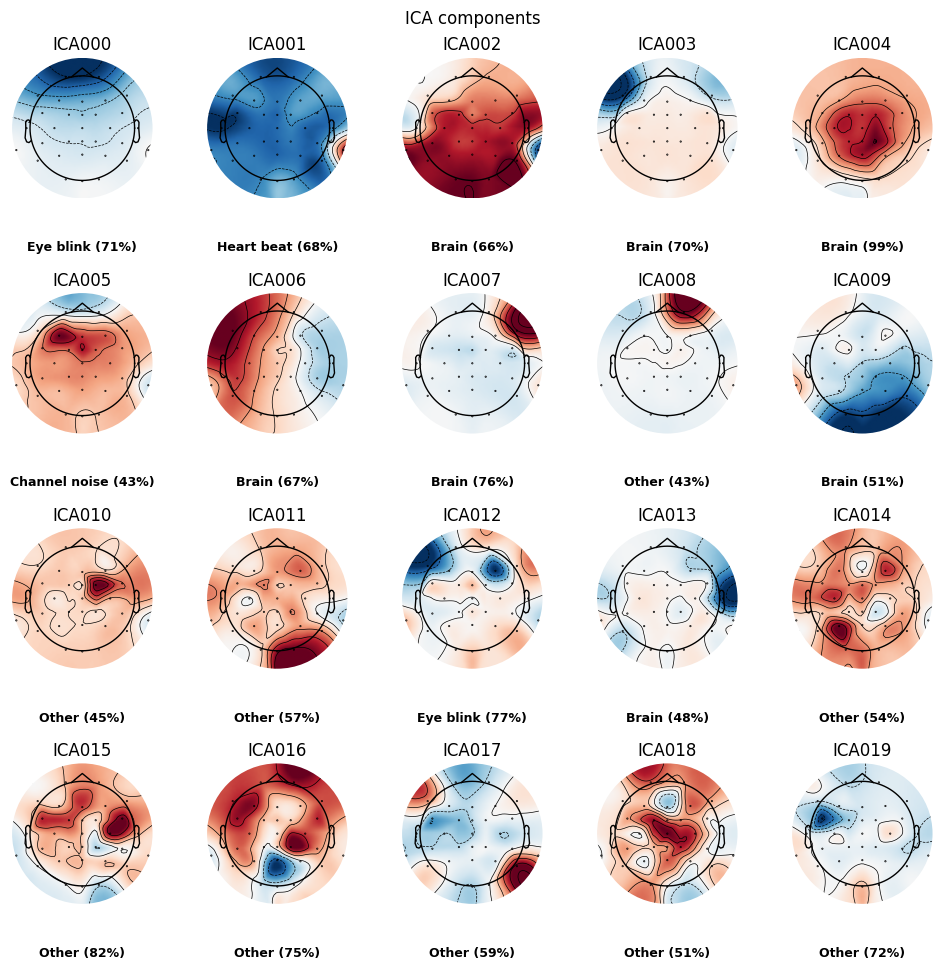

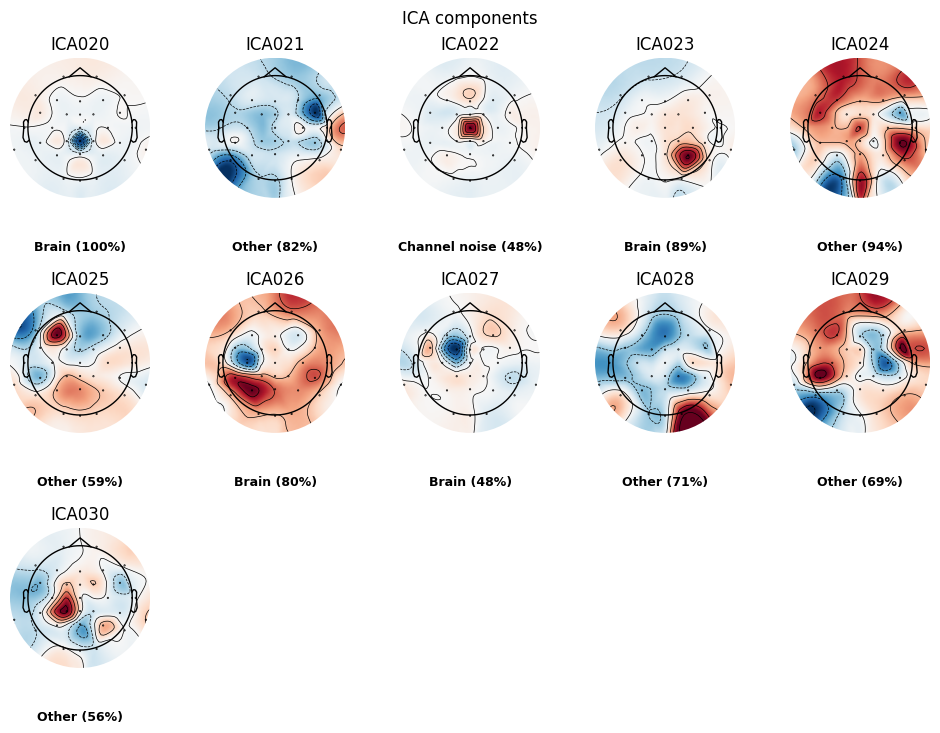

c:\Users\Zheng\Desktop\fourth semester\EEG\EEG_Reward-Processing_ERP\scripts\s04_ICA.py:64: RuntimeWarning: The provided Epochs instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  all_labels = iclabel_label_components(trials, ica)


Applying ICA to Raw instance
    Transforming to ICA space (31 components)
    Zeroing out 3 ICA components
    Projecting back using 32 PCA components


In [17]:
ica = get_ica(trials, config.PIPELINES[ACTIVE_PIPELINE]['ica_method'])

# for visualization only, may change this later (redundant claculation)
ic_labels = get_iclabel(trials, ica, method='iclabel')
iclabel_visualize(ica, ic_labels, trials)

if ACTIVE_PIPELINE == 'original':
    eeg_band_notch = iccomponent_removal_author(eeg_band_notch, trials, ica)
else: # proposed pipeline
    eeg_band_notch = iccomponent_removal_new(eeg_band_notch, trials, ica)

# Misc

## (TBD) Set to common locs and extra channel deletion

Removing extra channels: ['TP9', 'O1', 'O2', 'TP10', 'CPz']
Adding placeholders for missing channels: ['PO7', 'POz', 'PO8']
Interpolating channels: ['PO7', 'POz', 'PO8']
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 27 sensor positions
Interpolating 3 sensors


c:\Users\Zheng\Desktop\fourth semester\EEG\EEG_Reward-Processing_ERP\scripts\s05_interpolation.py:31: RuntimeWarning: Location for this channel is unknown or ambiguous; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
  data.add_reference_channels(missing_channels)


Using matplotlib as 2D backend.


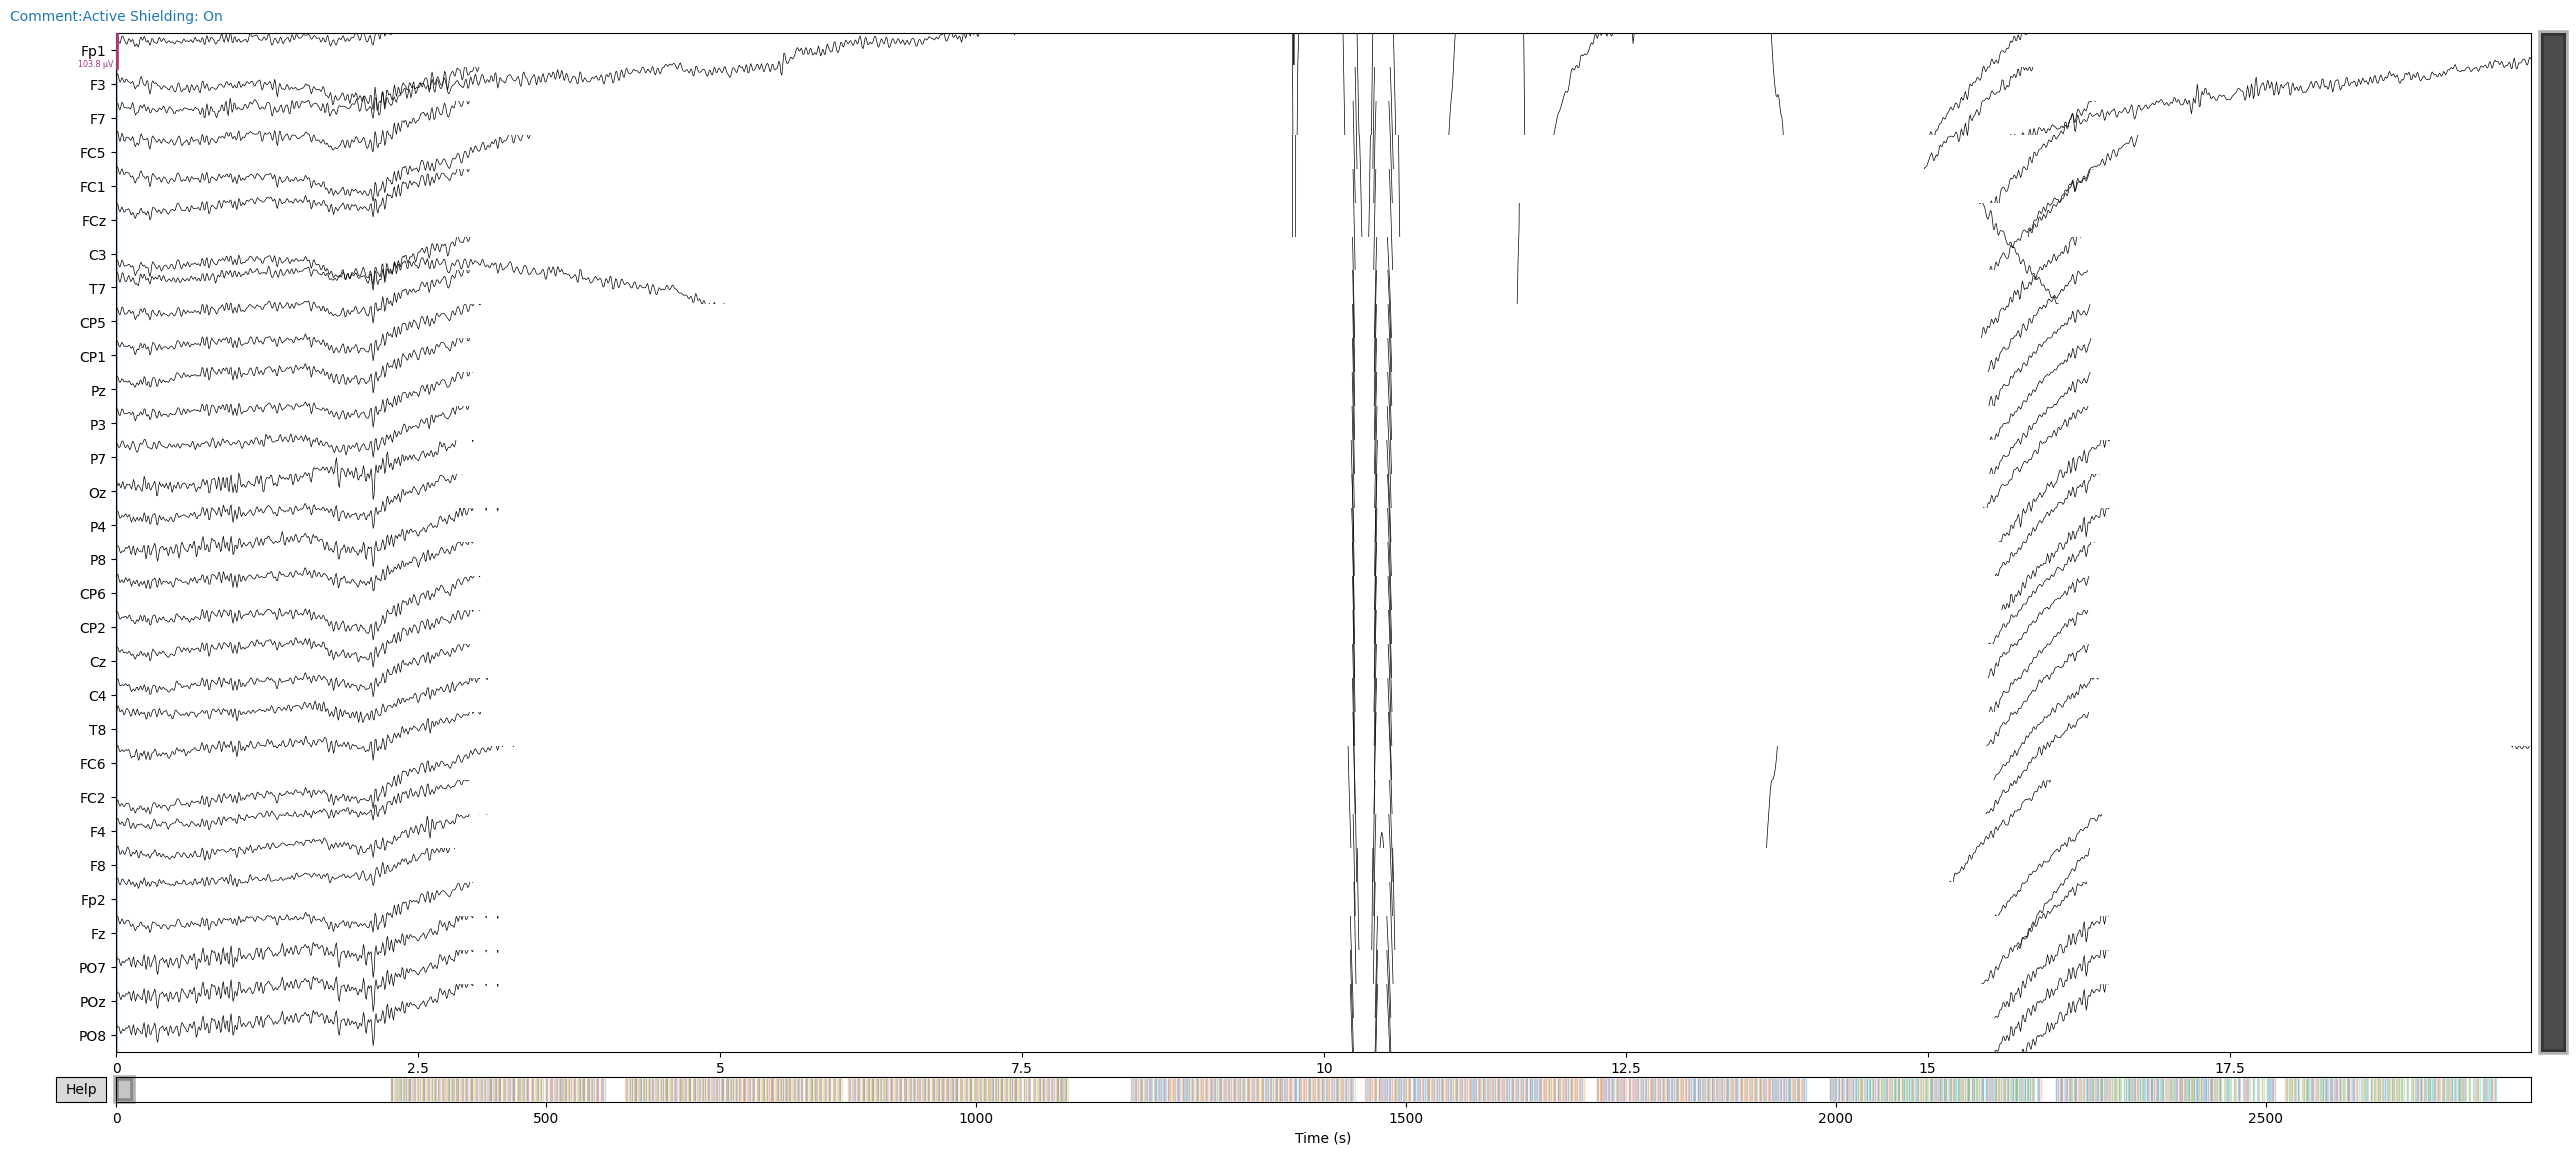

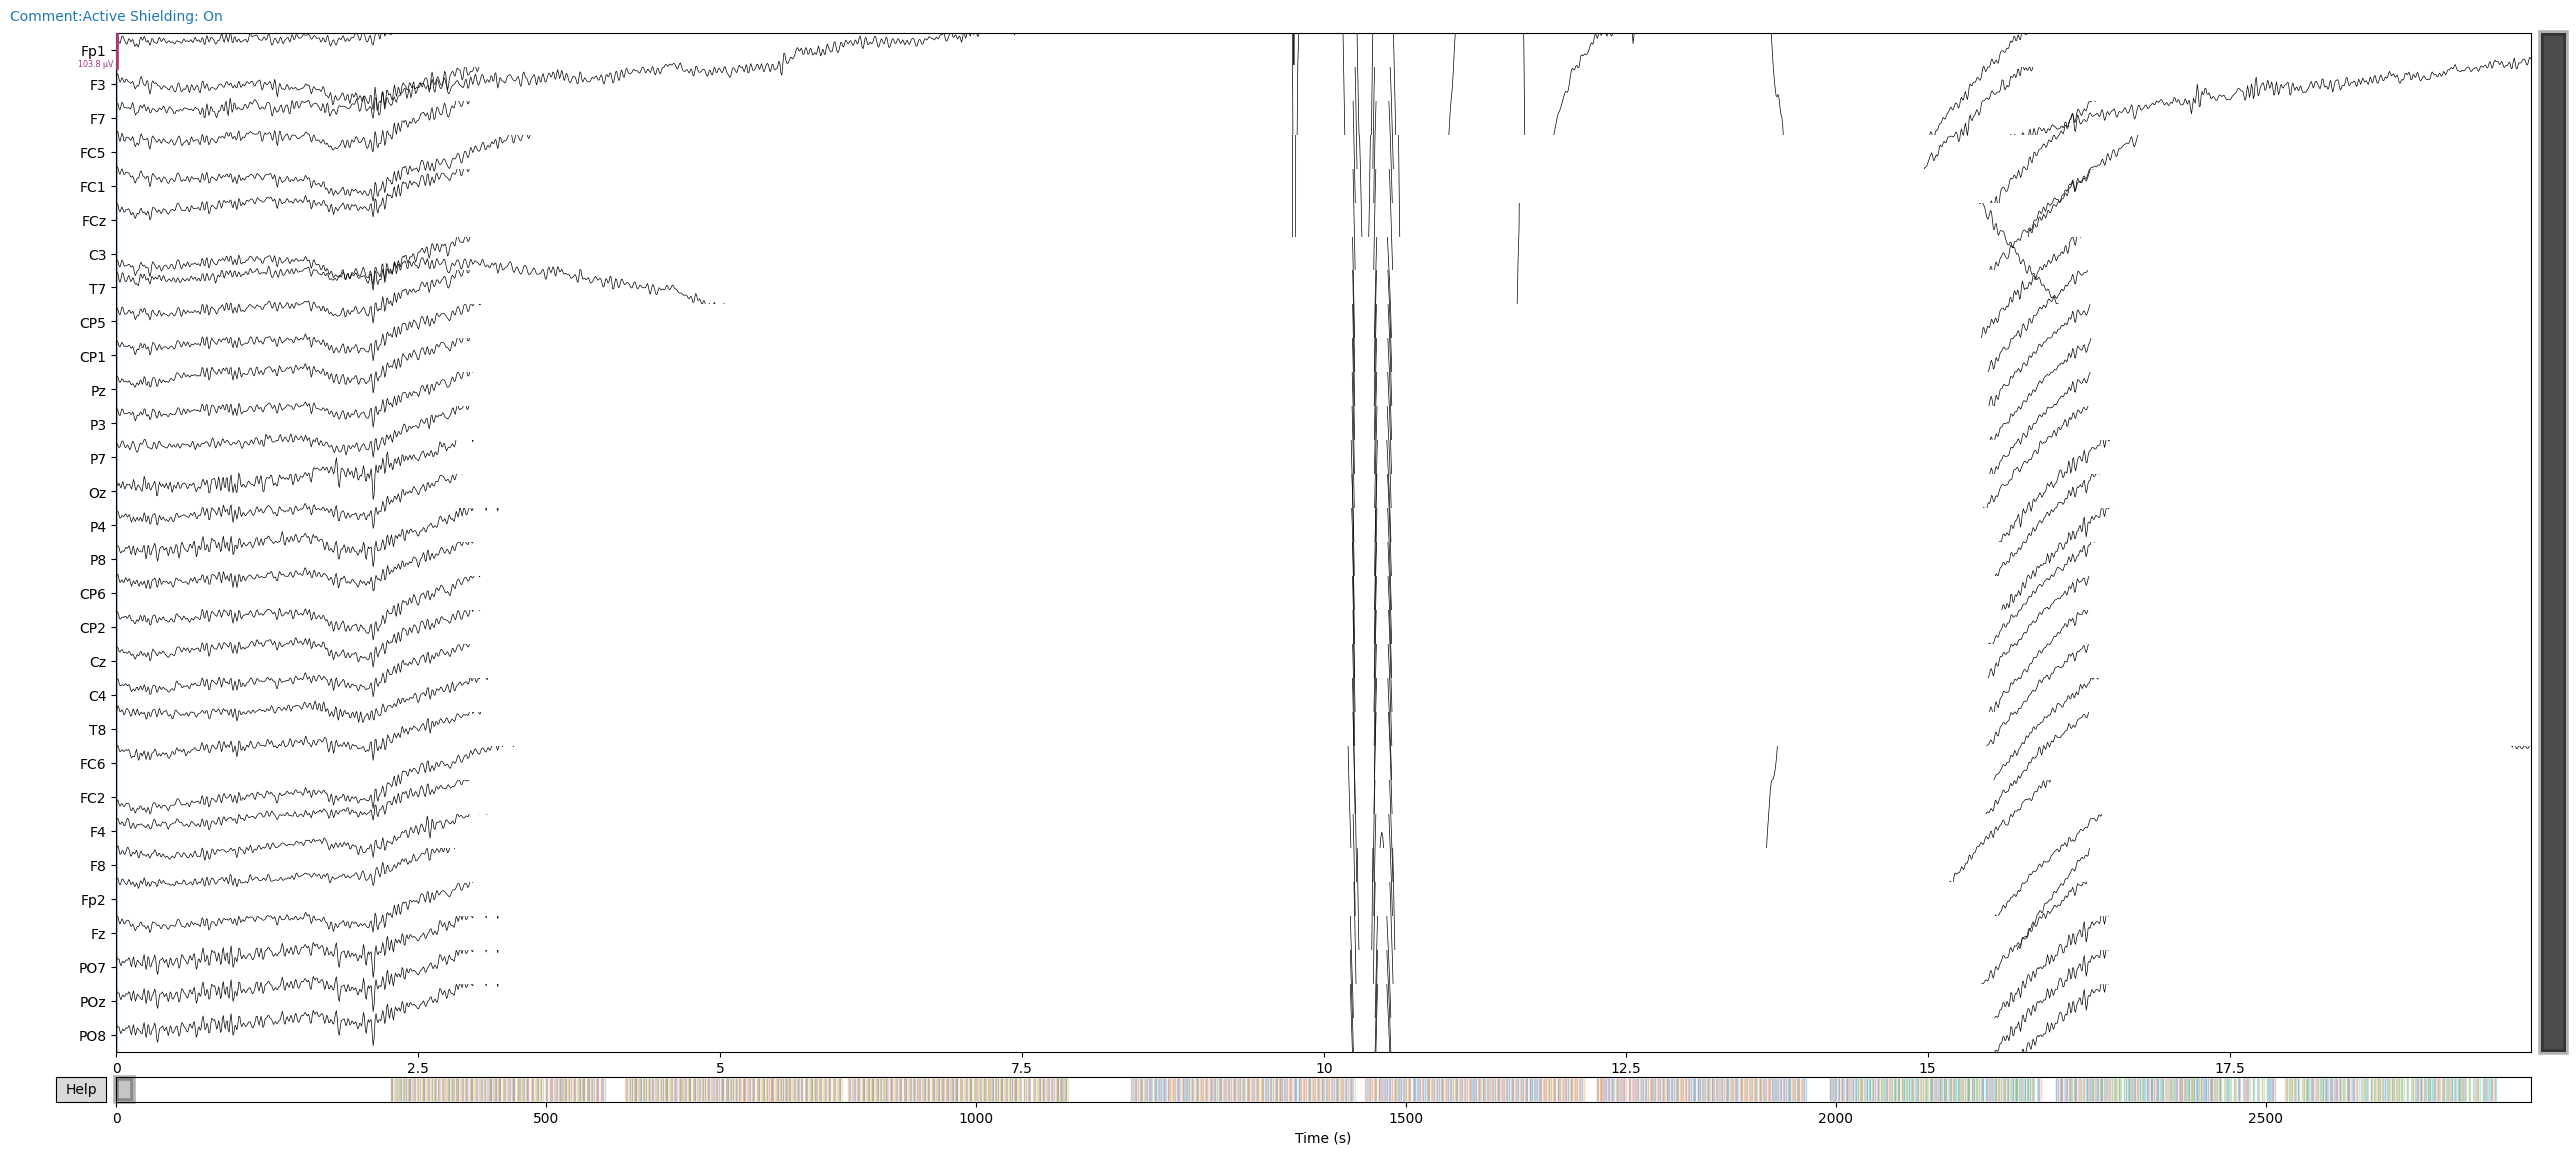

In [18]:
# 1. Load custom montage
common_montage = mne.channels.read_custom_montage(montage_common_path)

# 2. Interpolate
eeg_band_notch = interpolation(eeg_band_notch, common_montage)

eeg_band_notch.plot(
    n_channels=len(eeg_band_notch.ch_names), 
    duration=20, 
    scalings='auto', 
    title=f"Sub-{SUBJECT} Post-Interpolation)",
    block=True  # Setting block=True stops the script until you close the plot
)

## Remove the first few trials from each task

In [19]:
eeg_final = exclude_early_trials(eeg_band_notch, config.PIPELINES[ACTIVE_PIPELINE]['early_trial_deletion'])

Used Annotations descriptions: [np.str_('Comment:Active Shielding: On'), np.str_('Stimulus:S  1'), np.str_('Stimulus:S  2'), np.str_('Stimulus:S  3'), np.str_('Stimulus:S  4'), np.str_('Stimulus:S  5'), np.str_('Stimulus:S  6'), np.str_('Stimulus:S  7'), np.str_('Stimulus:S 11'), np.str_('Stimulus:S 12'), np.str_('Stimulus:S 13'), np.str_('Stimulus:S 14'), np.str_('Stimulus:S 15'), np.str_('Stimulus:S 16'), np.str_('Stimulus:S 17'), np.str_('Stimulus:S 21'), np.str_('Stimulus:S 22'), np.str_('Stimulus:S 23'), np.str_('Stimulus:S 24'), np.str_('Stimulus:S 25'), np.str_('Stimulus:S 26'), np.str_('Stimulus:S 27'), np.str_('Stimulus:S 31'), np.str_('Stimulus:S 32'), np.str_('Stimulus:S 33'), np.str_('Stimulus:S 34'), np.str_('Stimulus:S 35'), np.str_('Stimulus:S 36'), np.str_('Stimulus:S 37')]
Excluded 140 events (first 10 trials of each block).


>NOTE: 
- in theory, 3 tasks x 10 trials x 6 events = 180 events to be exlude
- but there might be some invalid response or to fast/slow reponses that do not have response/feedback

# Epoching & find leftover artifacts

In [20]:
rejection_params = config.PIPELINES[ACTIVE_PIPELINE]['rejection_params']['erp']
bad_channel_criteria = config.PIPELINES[ACTIVE_PIPELINE]['bad_channels_rejection_criteria']

if ACTIVE_PIPELINE == 'original':
    epochs_all, rejection_info = epoching_cust(epoch_dict, eeg_final, **rejection_params)
    find_bad_channels(epochs_all, reject_criteria=bad_channel_criteria, custom=True, rejection_info=rejection_info)
else: # proposed pipeline
    epochs_all = epoching(epoch_dict, eeg_final, **rejection_params)
    find_bad_channels(epochs_all, reject_criteria=bad_channel_criteria, custom=False)

Used Annotations descriptions: [np.str_('Comment:Active Shielding: On'), np.str_('Stimulus:S  1'), np.str_('Stimulus:S  2'), np.str_('Stimulus:S  3'), np.str_('Stimulus:S  4'), np.str_('Stimulus:S  5'), np.str_('Stimulus:S  6'), np.str_('Stimulus:S  7'), np.str_('Stimulus:S 11'), np.str_('Stimulus:S 12'), np.str_('Stimulus:S 13'), np.str_('Stimulus:S 14'), np.str_('Stimulus:S 15'), np.str_('Stimulus:S 16'), np.str_('Stimulus:S 17'), np.str_('Stimulus:S 21'), np.str_('Stimulus:S 22'), np.str_('Stimulus:S 23'), np.str_('Stimulus:S 24'), np.str_('Stimulus:S 25'), np.str_('Stimulus:S 26'), np.str_('Stimulus:S 27'), np.str_('Stimulus:S 31'), np.str_('Stimulus:S 32'), np.str_('Stimulus:S 33'), np.str_('Stimulus:S 34'), np.str_('Stimulus:S 35'), np.str_('Stimulus:S 36'), np.str_('Stimulus:S 37')]
Dropped 28 epochs: 3, 86, 95, 99, 106, 110, 122, 153, 160, 161, 169, 176, 177, 190, 205, 216, 227, 237, 238, 244, 253, 261, 262, 277, 286, 314, 315, 319
348
--- Channel Rejection Summary ---
Fp1: 7/3

# Make ERP

use trimmed mean
compare with the original method?

In [21]:
all_evokeds = get_evoked(epoch_dict, epochs_all, proportiontocut=config.PIPELINES[ACTIVE_PIPELINE]['evoked_proportiontocut'])

Using data from preloaded Raw for 59 events and 201 original time points ...
Using data from preloaded Raw for 57 events and 201 original time points ...
Using data from preloaded Raw for 28 events and 201 original time points ...
Using data from preloaded Raw for 16 events and 201 original time points ...
Using data from preloaded Raw for 32 events and 201 original time points ...
Using data from preloaded Raw for 19 events and 201 original time points ...
Using data from preloaded Raw for 47 events and 201 original time points ...
Using data from preloaded Raw for 62 events and 201 original time points ...


In [22]:
if INSPECTION_MODE == True:
    # butterfly graph for one condition
    evoked_Low_Low_Win = all_evokeds['Low-Low Win']
    evoked_Low_Low_Win.plot();

In [23]:
print(all_evokeds)

{'Low-Low Win': <Evoked | 'Low-Low Win' (average, N=59), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Low-Low Loss': <Evoked | 'Low-Low Loss' (average, N=57), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-Low Win': <Evoked | 'Mid-Low Win' (average, N=28), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-Low Loss': <Evoked | 'Mid-Low Loss' (average, N=16), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-High Win': <Evoked | 'Mid-High Win' (average, N=32), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'Mid-High Loss': <Evoked | 'Mid-High Loss' (average, N=19), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'High-High Win': <Evoked | 'High-High Win' (average, N=47), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>, 'High-High Loss': <Evoked | 'High-High Loss' (average, N=62), -0.2 – 0.6 s, baseline off, 30 ch, ~89 KiB>}


# RewP Calculation

In [24]:
rewp_calculation(all_evokeds, epoch_dict)

[Low-Low] Mean:  4.35 µV | P2P:  7.77 µV
[Mid-Low] Mean: -1.52 µV | P2P:  9.94 µV
[Mid-High] Mean:  1.87 µV | P2P:  8.49 µV
[High-High] Mean:  6.45 µV | P2P:  9.03 µV


{'Low-Low': {'mean': np.float64(4.347823330213497),
  'p2p': np.float64(7.768524537557426)},
 'Mid-Low': {'mean': np.float64(-1.5183237615475798),
  'p2p': np.float64(9.938348411765949)},
 'Mid-High': {'mean': np.float64(1.867406334524051),
  'p2p': np.float64(8.494272302734272)},
 'High-High': {'mean': np.float64(6.453564510407934),
  'p2p': np.float64(9.03114787836726)}}

# RewP Plotting

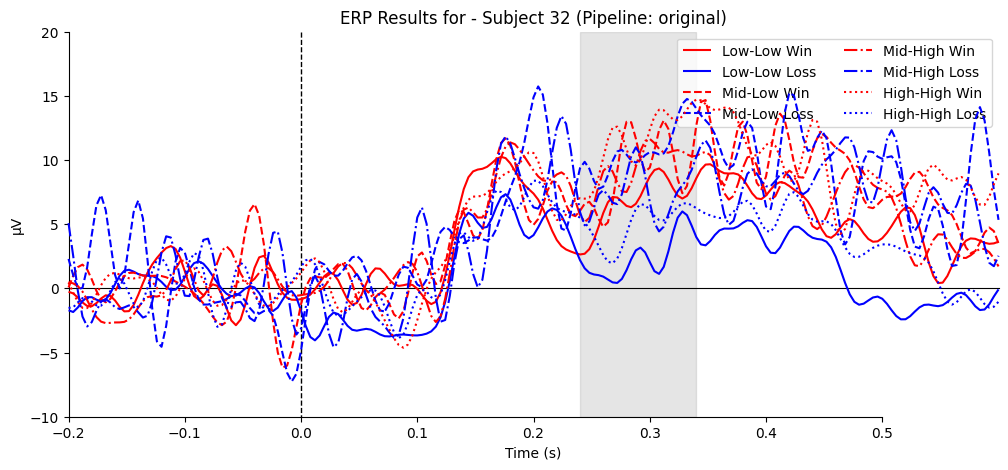

In [25]:
#NOTE: need to set y-axis to a fixed range for better comparison across subjects
plot_erp(all_evokeds, ylim=[-10, 20], diff=False, title=f"ERP Results for - Subject {SUBJECT} (Pipeline: {ACTIVE_PIPELINE})");

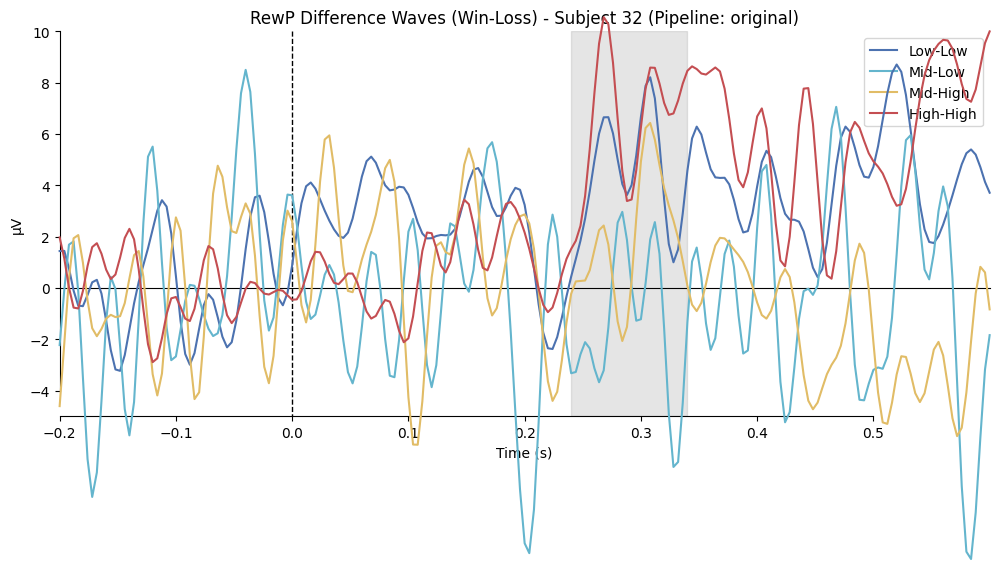

In [26]:
diff_evokeds = get_evoked_difference(all_evokeds)
plot_erp(diff_evokeds, diff=True, title=f"RewP Difference Waves (Win-Loss) - Subject {SUBJECT} (Pipeline: {ACTIVE_PIPELINE})")